### Evaluating and plotting causal pieces for Yin-Yang dataset

In [1]:
import torch
import numpy as np
from snnpiece.networks.MLPExpIF import MLPExpIF
from snnpiece.analysis import scan_through_plane, scan_through_line
from snnpiece.analysis import plot_mosaic, plot_spike_time

#### Plot causal pieces on a hyperplane in the input space, and plot the output spike time along a line (with different pieces marked by different colours)

Create dataset...


  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 400/400 [00:02<00:00, 148.30it/s]


Running network and extracting causal sets...


100%|██████████| 160/160 [00:05<00:00, 31.51it/s]


...

100%|██████████| 160000/160000 [00:00<00:00, 307346.65it/s]


Reducing to layerwise sets...


100%|██████████| 160000/160000 [00:00<00:00, 1328891.03it/s]


Count causal sets per neuron...


100%|██████████| 160000/160000 [00:00<00:00, 3538993.08it/s]


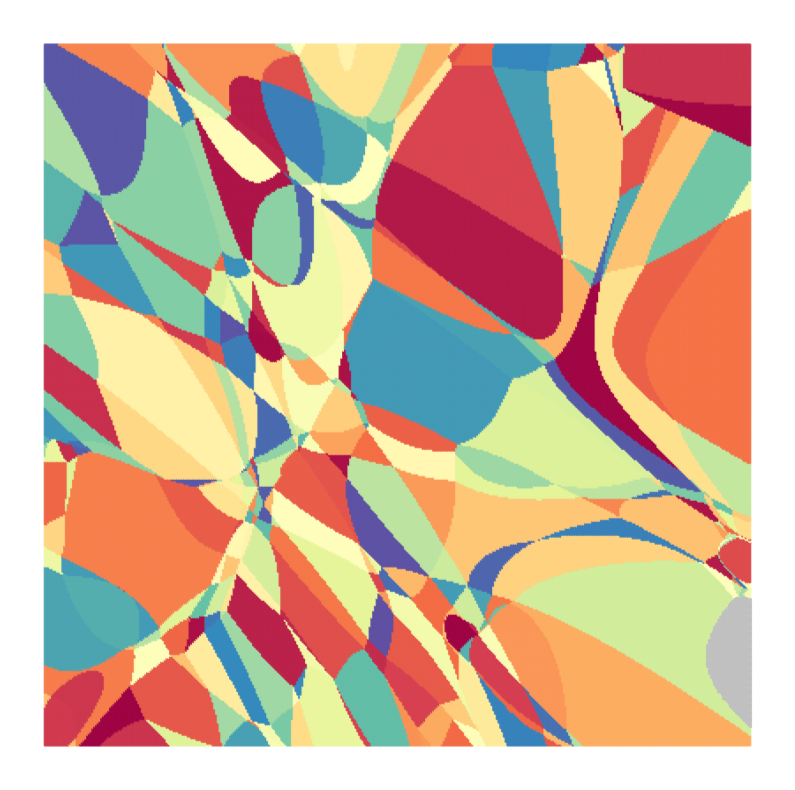

Running network and extracting causal sets...


100%|██████████| 2000/2000 [00:01<00:00, 1992.46it/s]


Index causal sets...


100%|██████████| 2000/2000 [00:00<00:00, 454150.18it/s]


Reducing to layerwise sets...


100%|██████████| 2000/2000 [00:00<00:00, 1152439.62it/s]


Count causal sets per neuron...


100%|██████████| 2000/2000 [00:00<00:00, 2142136.87it/s]


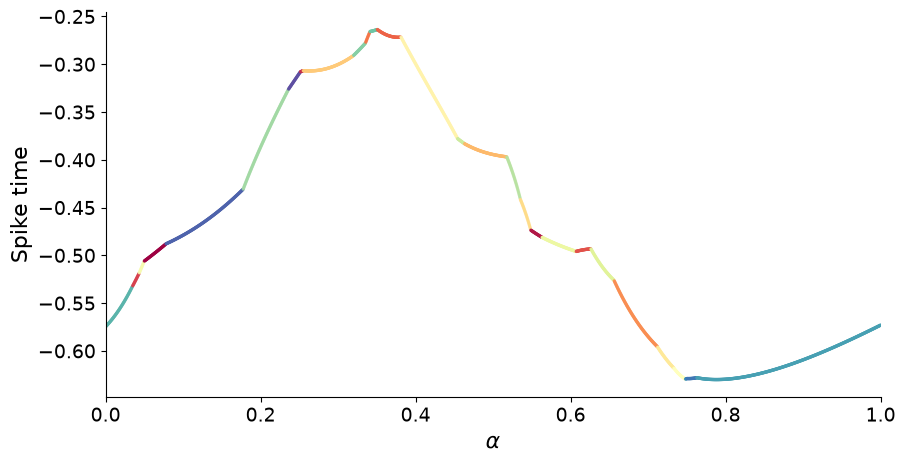

In [2]:
inp_dim = 40
model = MLPExpIF([inp_dim, 1], decoder = 'ttfs', seed = 42424242, last_spike= 10, return_detailed_output = True, init_type='normal_layerwise', init_params=[1.6916109,0.78568479,1.13212168,0.4872351])
dir0 = torch.Tensor(np.random.normal(0.,1.,size=(inp_dim)))
dir1 = torch.Tensor(np.random.normal(0.,1.,size=(inp_dim)))
origin = torch.Tensor(np.random.normal(0.,1., size=(inp_dim)))

outp = scan_through_plane(model, origin, dir0, dir1, steps=400)
plot_mosaic(outp, 0, 0)

outp = scan_through_line(model, origin, dir0, steps=2000)
plot_spike_time(outp, 0,0, xlim=(0., 1.), ylim = None)

#### Causal pieces for a network with one hidden layer

Create dataset...


100%|██████████| 400/400 [00:00<00:00, 6363.83it/s]


Running network and extracting causal sets...


100%|██████████| 160/160 [00:59<00:00,  2.68it/s]


Index causal sets...


100%|██████████| 160000/160000 [00:07<00:00, 21724.97it/s]


Reducing to layerwise sets...


100%|██████████| 160000/160000 [00:00<00:00, 233017.29it/s]


Count causal sets per neuron...


100%|██████████| 160000/160000 [00:00<00:00, 454207.35it/s]


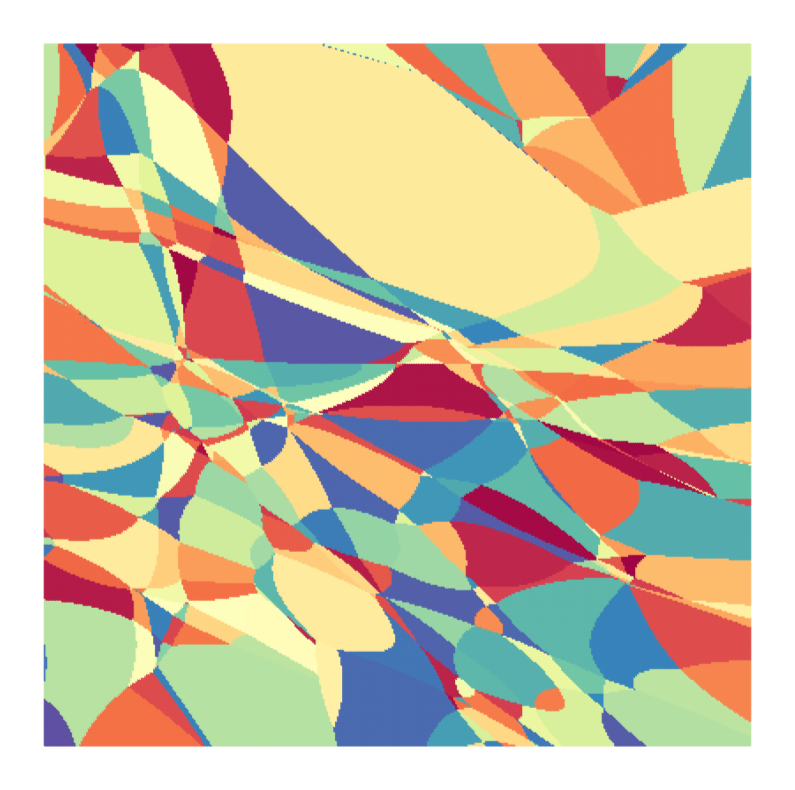

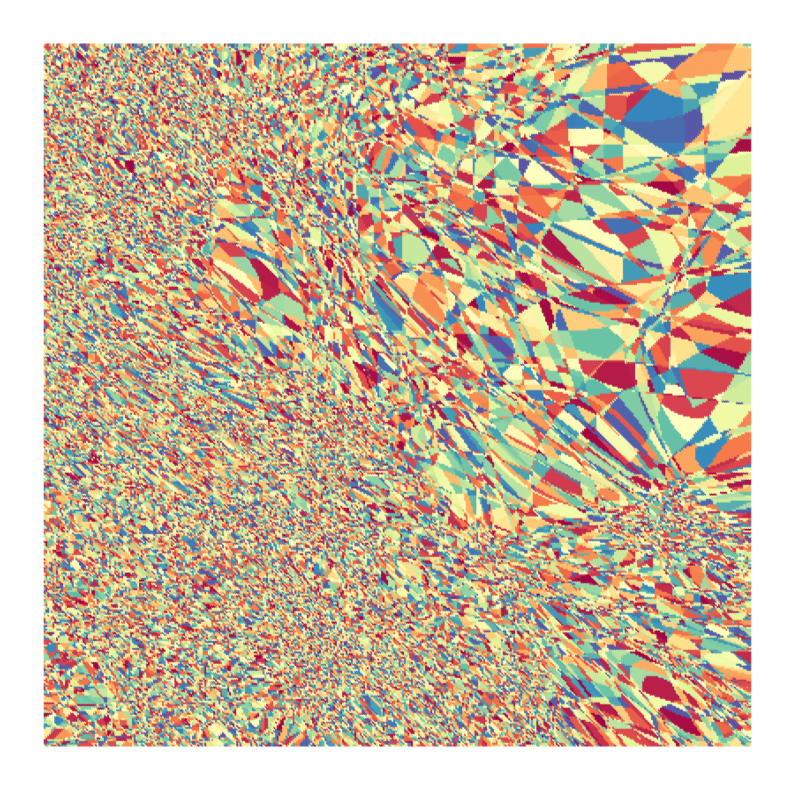

In [3]:
inp_dim = 40
hidden_dim = 40
model = MLPExpIF([inp_dim, hidden_dim, 1], decoder = 'ttfs', seed = 42424242, last_spike= 10, return_detailed_output = True, init_type='normal_layerwise', init_params=[1.6916109,0.78568479,1.13212168,0.4872351])
dir0 = torch.Tensor(np.random.normal(0.,1.,size=(inp_dim)))
dir1 = torch.Tensor(np.random.normal(0.,1.,size=(inp_dim)))
origin = torch.Tensor(np.random.normal(0.,1., size=(inp_dim)))
outp = scan_through_plane(model, origin, dir0, dir1, steps=400)

plot_mosaic(outp, 0, 0)
plot_mosaic(outp, 1, 0)

#### Evaluate and plot causal pieces using training samples

Running network and extracting causal sets...


100%|██████████| 1/1 [00:00<00:00,  2.59it/s]


Index causal sets...


100%|██████████| 5000/5000 [00:00<00:00, 94512.71it/s]


Reducing to layerwise sets...


...

100%|██████████| 5000/5000 [00:00<00:00, 48631.08it/s]


Reducing to layerwise sets...


100%|██████████| 5000/5000 [00:00<00:00, 337406.81it/s]


Count causal sets per neuron...


100%|██████████| 5000/5000 [00:00<00:00, 438459.54it/s]


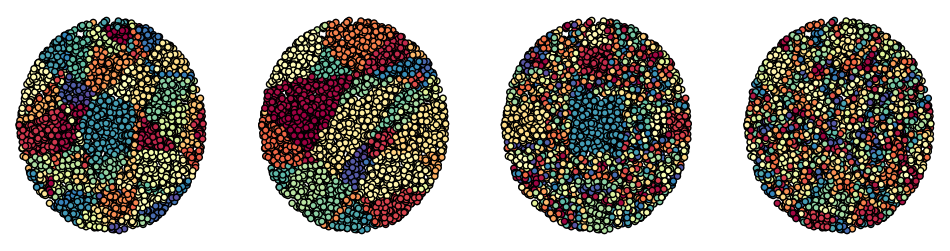

In [7]:
from snnpiece.analysis.datasets.yinyang import scan_through_dataset
from snnpiece.analysis import plot_mosaic_points
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(1,4, figsize=(12,3))

models = ['model_low_init.pt', 'model_low_trained.pt', 'model_high_init.pt', 'model_high_trained.pt']

for path, id in zip(models, [0,1,2,3]):
    torch.manual_seed(42)
    np.random.seed(42)
    model = MLPExpIF([4, 30, 3], seed=42424242, taus=0.5, decoder='linear', trainable_decoder=True, positive_weights=False, return_detailed_output=True, init_type='normal', init_params=[0, 0])
    model.load_state_dict(torch.load(path, weights_only=True, map_location=torch.device('cpu')))
    model.eval()
    output = scan_through_dataset(model, batchsize=5000)
    plot_mosaic_points(ax[id], output[0], 0, msize=20)